In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#pd.set_option('display.max_columns', None)
#pd.reset_option('display.max_columns')
#pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')

# EDA

- Podemos ver que os dados possuem tipos variados. 38 colunas do tipo numérico e 43 colunas do tipo categórica

In [8]:
df_treino = pd.read_csv('../input/train.csv')
#df_treino = df_treino.drop(['Id'],axis=1)
#df_treino
df_treino.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [18]:
#df_treino.select_dtypes(['int64','float64']).drop(['Id'],axis=1).corr()
df_treino_numericas = df_treino.select_dtypes(['int64','float64'])
df_treino_numericas.shape
#df_treino_numericas

(1460, 38)

In [20]:

df_treino_categoricas = df_treino.select_dtypes(['str'])

df_treino_categoricas.shape


(1460, 43)

- Há alguns casos com valores nulos. 
- Mas se baseando pela documentação, esses casos ocorrem geralmente quando a casa em si não possui aquela característica. Então deve ser importante considerar os casos em que essas variáveis possuíem valor nulo. Exemplo: PoolQC nulo implica que a casa não possui piscina. 

- Porém há algumas exceções que devem ser avaliadas.
- - Exemplo: LotFrontage nulo não implica que a casa não possui área conectada com a rua, já que isso poderia ser representado por LotFrontage = 0
- - Exemplo: GarageYrBlt nulo pode significar que a casa não possui garagem, mas não necessariamente

In [23]:
pd.set_option('display.max_rows', None)
df_treino_valores_nulos = df_treino.isnull().sum()
df_treino_valores_nulos[df_treino_valores_nulos>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

## Avaliando correlação entre as variáveis numéricas

- Olhando a correlação entre as variáveis numéricas apenas, podemos ver que em vários casos, há uma alta correlação, o que torna trabalhoso e demorado tratar os dados para usar uma regressão linear multivalorada. 

- Poderíamos inclusive fazer algum agrupamento entre os grandes grupos de variáveis. Por exemplo: há 2 variáveis categóricas que descrevem Roof; há 9 variáveis ( entre numéricas e categóricas) que descrevem Basement; há 7 variáveis (entre numéricas e categóricas) que descrevem Garage; etc

- Vale a pena analisar esses agrupamentos em mais detalhes

<Axes: >

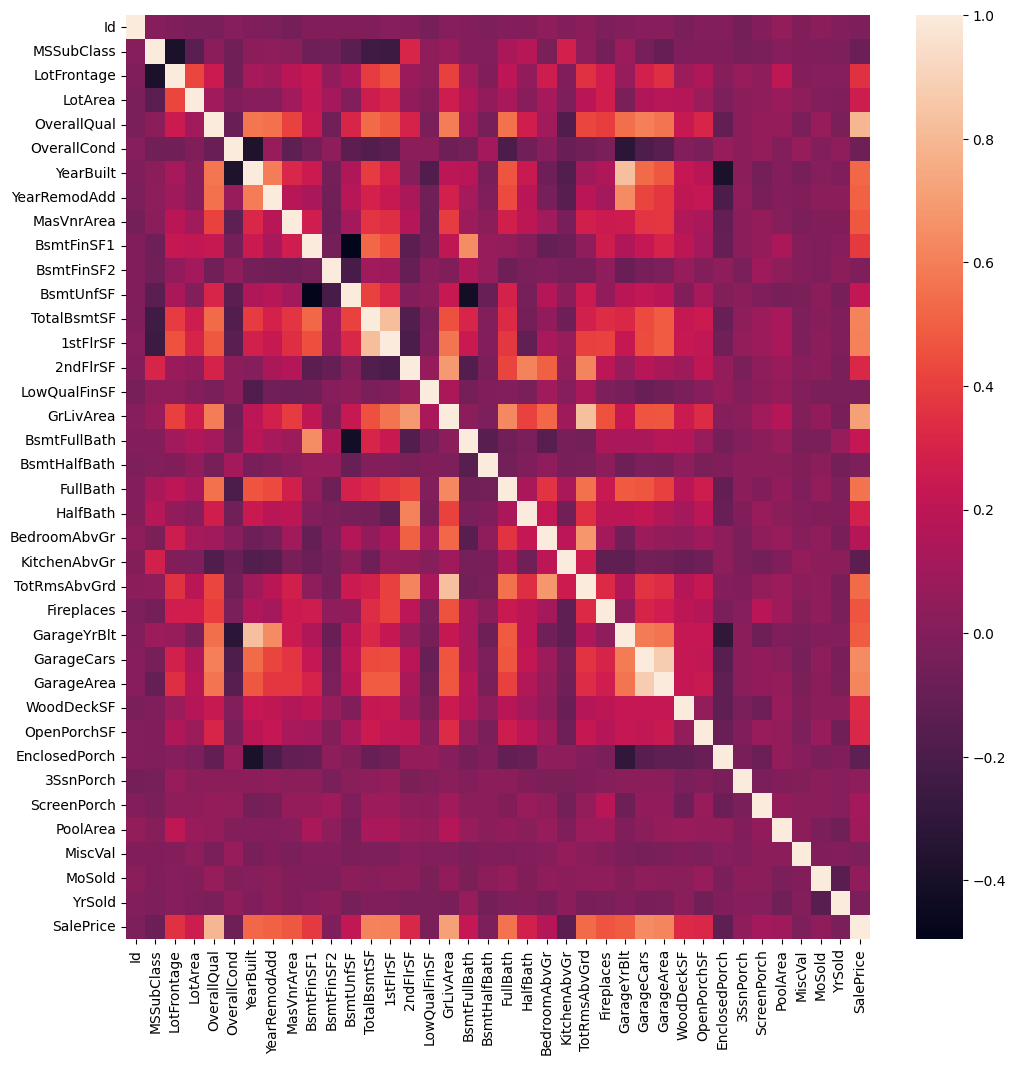

In [11]:
plt.figure(figsize=(12,12))
sns.heatmap(df_treino_numericas.corr())

- Há vários casos com taxa de correlação acima de 50% entre as variáveis numéricas

In [12]:
df_treino_numericas_corr = df_treino_numericas.corr()

taxa_relevancia = 0.5

df_treino_numericas_corr_relevantes = df_treino_numericas_corr[
    ((df_treino_numericas_corr > taxa_relevancia) & (df_treino_numericas_corr < 1))
    |((df_treino_numericas_corr < -taxa_relevancia) & (df_treino_numericas_corr > -1))]
df_treino_numericas_corr_relevantes.dropna(how='all',inplace=True)
df_treino_numericas_corr_relevantes.dropna(how='all',inplace=True,axis=1)
df_treino_numericas_corr_relevantes

,OverallQual,YearBuilt,YearRemodAdd,BsmtFinSF1,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,GarageYrBlt,GarageCars,GarageArea,SalePrice
OverallQual,NaN,0.572323,0.550684,NaN,0.537808,NaN,NaN,0.593007,NaN,0.550600,NaN,NaN,NaN,0.547766,0.600671,0.562022,0.790982
YearBuilt,0.572323,NaN,0.592855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.825667,0.537850,NaN,0.522897
YearRemodAdd,0.550684,0.592855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.642277,NaN,NaN,0.507101
BsmtFinSF1,NaN,NaN,NaN,NaN,0.522396,NaN,NaN,NaN,0.649212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalBsmtSF,0.537808,NaN,NaN,0.522396,NaN,0.819530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.613581
1stFlrSF,NaN,NaN,NaN,NaN,0.819530,NaN,NaN,0.566024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.605852
2ndFlrSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.687501,NaN,NaN,0.609707,0.502901,0.616423,NaN,NaN,NaN,NaN
GrLivArea,0.593007,NaN,NaN,NaN,NaN,0.566024,0.687501,NaN,NaN,0.630012,NaN,0.521270,0.825489,NaN,NaN,NaN,0.708624
BsmtFullBath,NaN,NaN,NaN,0.649212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FullBath,0.550600,NaN,NaN,NaN,NaN,NaN,NaN,0.630012,NaN,NaN,NaN,NaN,0.554784,NaN,NaN,NaN,0.560664


- A taxa de correlação mais alta de SalePrice está com OverallQual e YearBuilt. Acima de 70%

In [13]:

df_treino_numericas_corr_relevantes['SalePrice'].sort_values(ascending=False).dropna()


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice'>

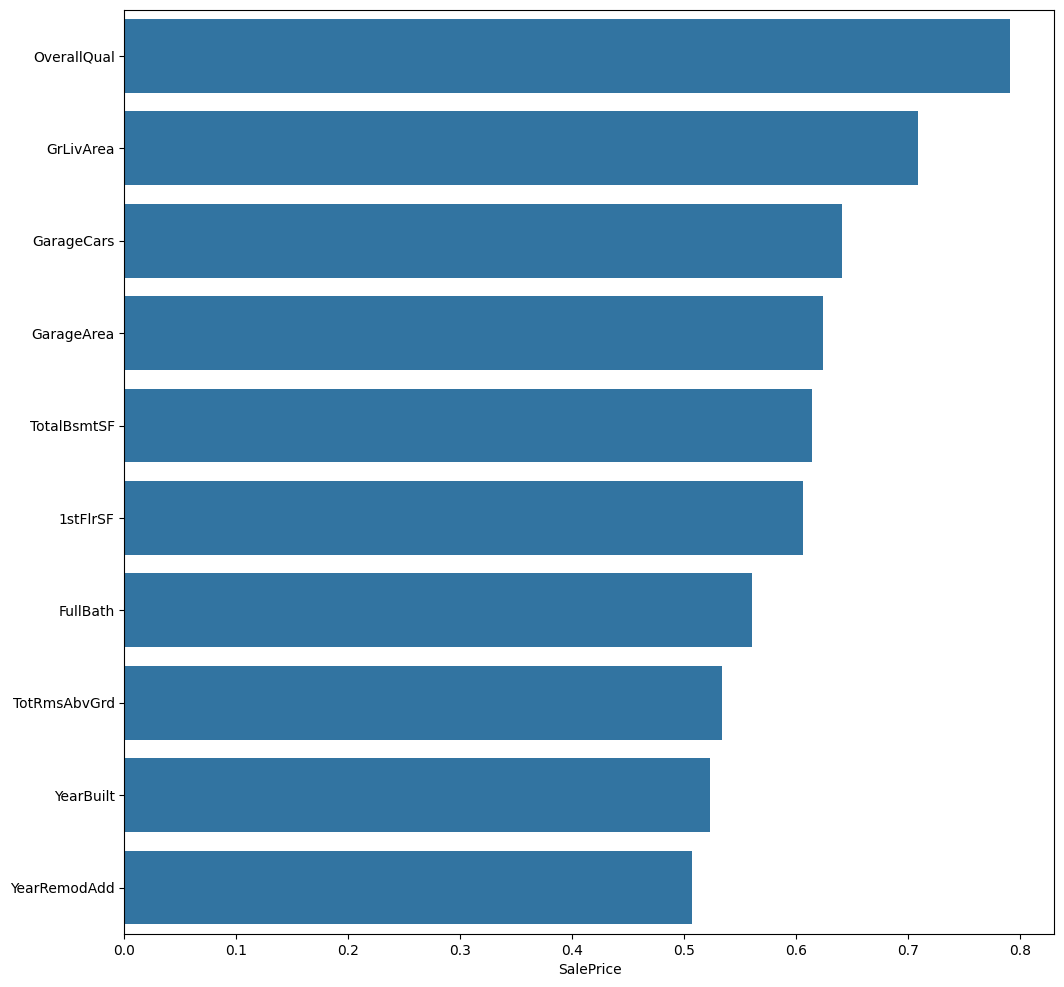

In [14]:
plt.figure(figsize=(12,12))
sns.barplot(
    df_treino_numericas_corr_relevantes['SalePrice'].sort_values(ascending=False).dropna(),
    orient='y'
)

## Avaliando correlação entre as variáveis categóricas

- Importante mapear os casos em que a variável é binária

## Avaliar os principais agrupamentos observados nas colunas:

### dwelling feature analysis

- MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

- MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density

- BldgType: Type of dwelling
		
       1Fam	Single-family Detached	
       2FmCon	Two-family Conversion; originally built as one-family dwelling
       Duplx	Duplex
       TwnhsE	Townhouse End Unit
       TwnhsI	Townhouse Inside Unit
	
- HouseStyle: Style of dwelling
	
       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level

### Lot feature analysis

- LotFrontage: Linear feet of street connected to property

- LotArea: Lot size in square feet

- LotShape: General shape of property

       Reg	Regular	
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular
       
- LandContour: Flatness of the property

       Lvl	Near Flat/Level	
       Bnk	Banked - Quick and significant rise from street grade to building
       HLS	Hillside - Significant slope from side to side
       Low	Depression

- LotConfig: Lot configuration

       Inside	Inside lot
       Corner	Corner lot
       CulDSac	Cul-de-sac
       FR2	Frontage on 2 sides of property
       FR3	Frontage on 3 sides of property
	
- LandSlope: Slope of property
		
       Gtl	Gentle slope
       Mod	Moderate Slope	
       Sev	Severe Slope

### feature analysis

# Data Pre Processing

## Numerical Data

In [11]:
# Remover ID
df_treino = df_treino.drop(['Id'],axis=1)
# Tratar casos nulos

## Categorical Data

In [ ]:
# Tratar casos em que a variável é binária
# Tratar casos nulos
# Criar variáveis dummys

# Training Model

In [ ]:
# RandomForestRegressor

# Evaluating